In [4]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
from oceantracker.read_output.python import load_output_files
# Here, we are calculating the connectivity "by hand", to illustrate the point.
# `load_stats_data`` does this automatically as well, which we'll show further down the line


In [ ]:
case_info_file_name = '../outputs/ptm/<run_output_dir>/caseInfo.json'


## Load gridded statistics

In [ ]:

# Load each status-group grid separately
stats_alive    = load_output_files.load_stats_data(case_info_file_name, 'alive_grid')
stats_stranded = load_output_files.load_stats_data(case_info_file_name, 'stranded_grid')
stats_outside  = load_output_files.load_stats_data(case_info_file_name, 'outside_grid')

# count has shape (n_times, n_release_groups, n_rows, n_cols)
# num_released has shape (n_times, n_release_groups)
num_released = stats_alive['num_released'][:, 0]  # same across all grids

count_alive    = stats_alive['count'][:, 0, :, :]
count_stranded = stats_stranded['count'][:, 0, :, :]
count_outside  = stats_outside['count'][:, 0, :, :]

# Connectivity: fraction of released particles in each cell at each time step
conn_alive    = count_alive    / num_released[:, np.newaxis, np.newaxis]
conn_stranded = count_stranded / num_released[:, np.newaxis, np.newaxis]
conn_outside  = count_outside  / num_released[:, np.newaxis, np.newaxis]

print(f'Grid shape (rows x cols): {count_alive.shape[1]} x {count_alive.shape[2]}')
print(f'Number of time steps:     {count_alive.shape[0]}')

# Combined sum across all trackable statuses should be <= 1
conn_total = conn_alive + conn_stranded + conn_outside
print(f'\nAt final timestep:')
print(f'  Peak connectivity (alive):    {np.nanmax(conn_alive[-1]):.4f}')
print(f'  Peak connectivity (stranded): {np.nanmax(conn_stranded[-1]):.4f}')
print(f'  Peak connectivity (outside):  {np.nanmax(conn_outside[-1]):.4f}')
print(f'  Sum alive+stranded+outside (should be <= 1): {np.nansum(conn_total[-1]):.4f}')


available variables: ['global_attributes', 'dimensions', 'limits', 'variable_attributes', 'x', 'num_released_total', 'count', 'number_released_each_release_group', 'cell_area', 'num_released', 'grid_spacings', 'release_group_names', 'count_all_alive_particles', 'x_grid', 'y_grid', 'time', 'y', 'time_var', 'date', 'stats_type', 'particle_status_flags', 'particle_release_groups', 'grid']
Grid shape (rows x cols): 1600 x 1600
Number of time steps:     16
(The first time step is at release, the second is at the end of the simulation i.e. after 3h)
Peak connectivity at last step: 0.0017
Sum of connectivity at last step (should be <= 1): 1.0000


## Setup

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
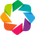

In [ ]:
import numpy as np
import xarray as xr
import holoviews as hv
import geoviews as gv
from pyproj import Transformer

from codebase.plot import (
    build_background,
    build_gridded_stats_layer,
    build_passage_fraction_layer,
)

hv.extension('bokeh')

BASE_NC = '../outputs/ptm/<run_output_dir>'
GRIDDED_NC = {
    'alive':    f'{BASE_NC}/stats_gridded_time_2D_006_alive_grid.nc',
    'stranded': f'{BASE_NC}/stats_gridded_time_2D_007_stranded_grid.nc',
    'outside':  f'{BASE_NC}/stats_gridded_time_2D_008_outside_grid.nc',
}
CONFIG = '../params/config.yaml'


## Spatial distributions

### Alive particles — connectivity (bias towards occupancy?)

In [ ]:
bg = build_background(CONFIG)

# Alive particles: moving + on_bottom + stationary
grid_alive = build_gridded_stats_layer(GRIDDED_NC['alive'], release_group=0,
                                       time_start='YYYY-MM-DD HH:MM',
                                       time_end='YYYY-MM-DD HH:MM',
                                       cmap='viridis',
                                       clim=(0, 0.01),
                                       agg='mean')

bg * grid_alive


:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [x,y]   (name,region_type)
   .Polygons.II :Polygons   [x,y]   (name,region_type)
   .QuadMesh.I  :QuadMesh   [x,y]   (connectivity)

### Alive particles — visit fraction (bias towards flowpath?)

In [ ]:
grid_passage = build_passage_fraction_layer(
    case_info_path=case_info_file_name,
    gridded_nc_path=GRIDDED_NC['alive'],
    release_group=0,
    time_start='YYYY-MM-DD HH:MM',
    time_end='YYYY-MM-DD HH:MM',
    fraction_to_read=None,
    cmap='plasma',
    clim=(0, 0.1),
)

bg * grid_passage


### Stranded particles

In [ ]:
# Stranded particles: stranded_by_tide
grid_stranded = build_gridded_stats_layer(GRIDDED_NC['stranded'], release_group=0,
                                          time_start='YYYY-MM-DD HH:MM',
                                          time_end='YYYY-MM-DD HH:MM',
                                          cmap='YlOrRd',
                                          clim=(0, 0.001))

bg * grid_stranded


## Particle status timeseries

In [ ]:
import pandas as pd

# ── Timeseries: alive / stranded / dead particle counts ──────────────────────
# Spatially sum gridded counts → total particles in each status at every timestep
total_alive    = count_alive.sum(axis=(1, 2))
total_stranded = count_stranded.sum(axis=(1, 2))
# "Dead" = released but no longer alive or stranded (outside domain + absorbed at sinks)
total_dead     = num_released - total_alive - total_stranded

# stats_alive['time'] is Unix epoch seconds (float) → convert with unit='s'
times = pd.to_datetime(stats_alive['time'], unit='s')

curve_alive    = hv.Curve((times, total_alive),    kdims=['Time'], vdims=['Count'], label='Alive'   ).opts(color='steelblue', line_width=2)
curve_stranded = hv.Curve((times, total_stranded), kdims=['Time'], vdims=['Count'], label='Stranded').opts(color='orange',    line_width=2)
curve_dead     = hv.Curve((times, total_dead),     kdims=['Time'], vdims=['Count'], label='Dead'    ).opts(color='crimson',   line_width=2)

fontsize = {'title': 16, 'labels': 16, 'xticks': 14, 'yticks': 14, 'legend': 14}

(curve_alive * curve_stranded * curve_dead).opts(
    hv.opts.Curve(width=800, height=400, show_grid=True, tools=['hover'], fontsize=fontsize),
    hv.opts.Overlay(title='Particle Status Over Time', legend_position='right',
                    xlabel='Time', ylabel='Particle Count'),
)
